In [1]:
from abc import abstractmethod,ABC
from  tqdm import tqdm
from time import sleep
from datetime import datetime, timezone
import pandas as pd
import ccxt

In [2]:
okx = ccxt.okx()

In [18]:
time_since  ='2025-09-01'
since = int(datetime.strptime(time_since, '%Y-%m-%d').timestamp() * 1000)

In [22]:
df = okx.fetchFundingRateHistory(symbol='SOL/USDT:USDT', since=since, limit=100)

In [23]:
pd.DataFrame(df)

,info,symbol,fundingRate,timestamp,datetime
0,"{'formulaType': 'withRate', 'fundingRate': '0....",SOL/USDT:USDT,0.000077,1756656000000,2025-08-31T16:00:00.000Z
1,"{'formulaType': 'withRate', 'fundingRate': '0....",SOL/USDT:USDT,0.000075,1756684800000,2025-09-01T00:00:00.000Z
2,"{'formulaType': 'withRate', 'fundingRate': '0....",SOL/USDT:USDT,0.000035,1756713600000,2025-09-01T08:00:00.000Z
3,"{'formulaType': 'withRate', 'fundingRate': '0....",SOL/USDT:USDT,0.000024,1756742400000,2025-09-01T16:00:00.000Z
4,"{'formulaType': 'withRate', 'fundingRate': '-0...",SOL/USDT:USDT,-0.000003,1756771200000,2025-09-02T00:00:00.000Z
...,...,...,...,...,...
95,"{'formulaType': 'withRate', 'fundingRate': '-0...",SOL/USDT:USDT,-0.000029,1759392000000,2025-10-02T08:00:00.000Z
96,"{'formulaType': 'withRate', 'fundingRate': '-0...",SOL/USDT:USDT,-0.000062,1759420800000,2025-10-02T16:00:00.000Z
97,"{'formulaType': 'withRate', 'fundingRate': '-0...",SOL/USDT:USDT,-0.000049,1759449600000,2025-10-03T00:00:00.000Z
98,"{'formulaType': 'withRate', 'fundingRate': '0....",SOL/USDT:USDT,0.000054,1759478400000,2025-10-03T08:00:00.000Z


In [37]:
df = pd.DataFrame(okx.fetchOHLCV(symbol='SOL/USDT:USDT',timeframe='1h',params={'type':'HistoryCandles'},since = since),columns=['timestamp','open','high','low','close','volume'])

In [38]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

In [39]:
df

,timestamp,open,high,low,close,volume
0,2025-08-31 16:00:00,204.48,205.23,203.58,205.02,324135.73
1,2025-08-31 17:00:00,205.03,205.57,204.40,204.85,236734.61
2,2025-08-31 18:00:00,204.84,205.61,204.57,205.58,156181.07
3,2025-08-31 19:00:00,205.58,205.88,204.33,204.54,145286.30
4,2025-08-31 20:00:00,204.54,205.14,204.19,204.75,113883.91
...,...,...,...,...,...,...
95,2025-09-04 15:00:00,205.27,205.28,203.22,203.66,952071.82
96,2025-09-04 16:00:00,203.67,204.77,203.43,204.50,330244.56
97,2025-09-04 17:00:00,204.50,205.08,203.81,203.85,251706.36
98,2025-09-04 18:00:00,203.87,204.61,202.18,202.98,478824.97


In [41]:
all_info=[]

In [48]:
time_since  ='2024-09-01'
since = int(datetime.strptime(time_since, '%Y-%m-%d').timestamp() * 1000)

In [52]:
while True:
    batch = okx.fetchOHLCV(symbol='SOL/USDT:USDT', since=since, limit=200, params={'type':'HistoryCandles'},timeframe='1h')
    if len(batch) == 0:
        break
    all_info.extend(batch)
    since = int(batch[-1][0]) + 1  # Move to the next timestamp
    print(f"Fetched {len(batch)} records, next since: {pd.to_datetime(since, unit='ms')}")
    sleep(1)  # To respect rate limits

Fetched 100 records, next since: 2025-06-02 15:00:00.001000
Fetched 100 records, next since: 2025-06-06 19:00:00.001000
Fetched 100 records, next since: 2025-06-10 23:00:00.001000
Fetched 100 records, next since: 2025-06-15 03:00:00.001000
Fetched 100 records, next since: 2025-06-19 07:00:00.001000
Fetched 100 records, next since: 2025-06-23 11:00:00.001000
Fetched 100 records, next since: 2025-06-27 15:00:00.001000
Fetched 100 records, next since: 2025-07-01 19:00:00.001000
Fetched 100 records, next since: 2025-07-05 23:00:00.001000
Fetched 100 records, next since: 2025-07-10 03:00:00.001000
Fetched 100 records, next since: 2025-07-14 07:00:00.001000
Fetched 100 records, next since: 2025-07-18 11:00:00.001000
Fetched 100 records, next since: 2025-07-22 15:00:00.001000
Fetched 100 records, next since: 2025-07-26 19:00:00.001000
Fetched 100 records, next since: 2025-07-30 23:00:00.001000
Fetched 100 records, next since: 2025-08-04 03:00:00.001000
Fetched 100 records, next since: 2025-08

In [ ]:
def fetch_funding_rate_impl(exchange, symbol, since, limit=100):
        all_infos = []
        batch = []
        if since is None:
            since = '2021-01-01'  # Default start date
        else:
            since_api = int(pd.to_datetime(since).timestamp() * 1000)  # Convert to ms
        now_ts = int(datetime.now(timezone.utc).timestamp() *1000)
        prev_last_ts =0
        page = 0
        limit_per_page = limit if limit and limit < 1000 else 1000  
        with tqdm(desc=f"{exchange.id} {symbol} funding history", unit="page") as pbar:
            while True:
                try:
                    batch = exchange.fetch_funding_rate_history(
                        symbol,
                        since=since_api,
                        limit=limit_per_page,
                        params={
                            "startTime": since_api,
                        }
                    )
                except Exception as e:
                    print(f"Error fetching {symbol} on {exchange}", e)
                all_infos.extend(fr['info'] if 'info' in fr else fr for fr in batch)

                # Get timestamp from last entry, try different approaches
                last_fr = batch[-1]

                since_api = last_fr['timestamp']
                if since_api >= now_ts + 1  or since_api == prev_last_ts or len(batch) < limit_per_page:
                    print(f"Reached current data at page {page}")
                    break                
                page += 1
                pbar.update(1)
        df = pd.DataFrame(all_infos)
        df['fundingRateTimestamp'] = pd.to_datetime(df['fundingRateTimestamp'], unit='ms')
        return df

In [124]:
df = fetch_funding_rate_impl(ccxt.bybit(), 'BTC/USDT:USDT', since = '2021-01-01', limit=1000)

bybit BTC/USDT:USDT funding history: 25page [00:12,  2.06page/s]

Reached current data at page 25



/var/folders/l0/ycf7g2hn2sj3jcdc9w2z3k6c0000gn/T/ipykernel_40140/3967492230.py:58: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['fundingRateTimestamp'] = pd.to_datetime(df['fundingRateTimestamp'], unit='ms')


In [125]:
df

,symbol,fundingRate,fundingRateTimestamp
0,BTCUSDT,0.0001,2021-01-01 08:00:00
1,BTCUSDT,0.0001,2021-01-01 16:00:00
2,BTCUSDT,0.0006425,2021-01-02 00:00:00
3,BTCUSDT,0.00020649,2021-01-02 08:00:00
4,BTCUSDT,0.0001,2021-01-02 16:00:00
...,...,...,...
5154,BTCUSDT,0.00007622,2025-09-15 00:00:00
5155,BTCUSDT,0.0001,2025-09-15 08:00:00
5156,BTCUSDT,0.0000798,2025-09-15 16:00:00
5157,BTCUSDT,0.0001,2025-09-16 00:00:00


In [ ]:
all_infos = []
from datetime import datetime, timezone, timedelta

batch = []
since = '2021-01-01'  # Default start date
since_api = int(pd.to_datetime(since).timestamp() * 1000)  # Convert to ms
dt = datetime.now(timezone.utc) - timedelta(hours=8)
now_ts = int(dt.timestamp() * 1000)
end_time = now_ts
prev_last_ts =0
page = 0
limit_per_page = 200
exchange = ccxt.hyperliquid()
symbol = 'BTC/USDT:USDT'

In [92]:
batch = exchange.fetch_funding_rate_history(
    symbol,
    since=since_api,
    limit=limit_per_page,
)
last_fr = batch[-1]


df = pd.DataFrame([fr['info'] if 'info' in fr else fr for fr in batch])
df['fundingRateTimestamp'] = pd.to_datetime(df['fundingRateTimestamp'], unit='ms')

/var/folders/l0/ycf7g2hn2sj3jcdc9w2z3k6c0000gn/T/ipykernel_40140/1144965046.py:10: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['fundingRateTimestamp'] = pd.to_datetime(df['fundingRateTimestamp'], unit='ms')


In [116]:

while True:
        batch = exchange.fetch_funding_rate_history(
            symbol,
            since=since_api,
            limit=limit_per_page,
            params={
                "startTime": since_api,
                # "endTime": end_time,
            }
        )
        all_infos.extend(fr['info'] if 'info' in fr else fr for fr in batch)
         # Get timestamp from last entry, try different approaches
        last_fr = batch[-1]
        since_api = last_fr['timestamp']
        print(pd.to_datetime(since_api, unit='ms'))
        if not batch or since_api >= now_ts:
            break

df = pd.DataFrame(all_infos)
df['fundingRateTimestamp'] = pd.to_datetime(df['fundingRateTimestamp'], unit='ms')

2021-03-08 16:00:00
2021-05-14 08:00:00
2021-07-20 00:00:00
2021-09-24 16:00:00
2021-11-30 08:00:00
2022-02-05 00:00:00
2022-04-12 16:00:00
2022-06-18 08:00:00
2022-08-24 00:00:00
2022-10-29 16:00:00
2023-01-04 08:00:00
2023-03-12 00:00:00
2023-05-17 16:00:00
2023-07-23 08:00:00
2023-09-28 00:00:00
2023-12-03 16:00:00
2024-02-08 08:00:00
2024-04-15 00:00:00
2024-06-20 16:00:00
2024-08-26 08:00:00
2024-11-01 00:00:00
2025-01-06 16:00:00
2025-03-14 08:00:00
2025-05-20 00:00:00
2025-07-25 16:00:00
2025-09-16 08:00:00


/var/folders/l0/ycf7g2hn2sj3jcdc9w2z3k6c0000gn/T/ipykernel_40140/1431323328.py:20: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['fundingRateTimestamp'] = pd.to_datetime(df['fundingRateTimestamp'], unit='ms')


In [117]:
df

,symbol,fundingRate,fundingRateTimestamp
0,BTCUSDT,0.0001,2021-01-01 08:00:00
1,BTCUSDT,0.0001,2021-01-01 16:00:00
2,BTCUSDT,0.0006425,2021-01-02 00:00:00
3,BTCUSDT,0.00020649,2021-01-02 08:00:00
4,BTCUSDT,0.0001,2021-01-02 16:00:00
...,...,...,...
5154,BTCUSDT,0.00007622,2025-09-15 00:00:00
5155,BTCUSDT,0.0001,2025-09-15 08:00:00
5156,BTCUSDT,0.0000798,2025-09-15 16:00:00
5157,BTCUSDT,0.0001,2025-09-16 00:00:00


In [3]:
binance = ccxt.binance()

In [ ]:
def _symbol_loader(markets, exchange):
    supported_exchanges = {"binance", "bybit", "bitget", "gateio"}
    if exchange.id in supported_exchanges:
        return [
            symbol for symbol, market in markets.items()
            if market.get('swap', False) and market.get('contract', False)
        ]   
    return []   

In [5]:
markets = binance.load_markets()

In [9]:
result = [
            symbol for symbol, market in markets.items()
            if market.get('swap', False) and market.get('contract', False)
        ]   

In [3]:
import numpy as np

def max_drawdown(values):
    values = np.array(values)
    running_max = np.maximum.accumulate(values)
    print(running_max)
    drawdowns = (values - running_max) / running_max
    return drawdowns.min()  # most negative value

In [4]:
equity = [100, 120, 115, 90, 130, 125]
print(max_drawdown(equity))  # -> -0.25 (i.e. -25%)


[100 120 120 120 130 130]
-0.25


In [5]:
import numpy as np
import pandas as pd

# Example time series of cumulative returns (or portfolio values)
values = pd.Series([100, 110, 105, 120, 90, 95, 130])

# Compute running maximum (the peaks)
running_max = values.cummax()

# Compute drawdowns
drawdowns = (running_max - values) / running_max

# Maximum Drawdown
mdd = drawdowns.max()

print("Maximum Drawdown:", mdd)



Maximum Drawdown: 0.25


In [9]:
(values - running_max).min()

-30

In [10]:
# Example daily returns of an asset
returns = pd.Series([0.01, -0.005, 0.002, 0.015, -0.01, 0.007])

# Assume risk-free rate = 0 for simplicity
risk_free_rate = 0.0

# Excess returns
excess_returns = returns - risk_free_rate

# Sharpe ratio (annualized assuming 252 trading days)
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

print("Sharpe Ratio:", sharpe_ratio)


Sharpe Ratio: 5.341552129242646


In [8]:
import pandas as pd
import numpy as np
from time import perf_counter

def timeit(fn, repeat=3):
    best = float("inf")
    for _ in range(repeat):
        t0 = perf_counter()
        fn()
        best = min(best, perf_counter() - t0)
    return best

N = 1_000_00  # reduce if your laptop struggles
df = pd.DataFrame({
    "a": np.random.randn(N),
    "b": np.random.randn(N),
    "c": np.random.randint(0, 10, size=N)
})
# Try different index types to see how label lookup affects .loc:
ri = pd.RangeIndex(N)  # arithmetic lookup
si = pd.Index([f"id{i:07d}" for i in range(N)])  # hashed lookup
ti = pd.date_range("2024-01-01", periods=N, freq="T")  # sorted -> fast range slices

def bench_on(index, label_for_row_12345):
    d = df.copy()
    d.index = index

    print(f"\n=== Index type: {type(index).__name__} ===")

    # A) Vectorized vs row-iteration (includes loc implicitly via row Series in iterrows)
    def vec(): d["a"].mul(d["b"]).sum()
    def itertuples_sum():
        s = 0.0
        for row in d.itertuples(index=False):
            s += row.a * row.b
        return s
    def iterrows_sum():
        s = 0.0
        for _, row in d.iterrows():
            s += row["a"] * row["b"]    # this uses Series (slower)
        return s

    print("vectorized:", timeit(vec))
    print("itertuples():", timeit(itertuples_sum))
    print("iterrows():", timeit(iterrows_sum))

    # B) Scalar access: iat/at vs iloc/loc
    def scalar_iat():
        s = 0.0
        for i in range(50_000):
            s += d.iat[i % len(d), 0]
        return s
    def scalar_at():
        s = 0.0
        lab = label_for_row_12345
        n = len(d)
        for i in range(50_000):
            # walk labels in a wrap-around manner
            if isinstance(index, pd.RangeIndex):
                lbl = i % n
            elif isinstance(index, pd.DatetimeIndex):
                lbl = index[i % n]
            else:
                lbl = f"id{(i % n):07d}"
            s += d.at[lbl, "a"]
        return s
    def scalar_iloc():
        s = 0.0
        for i in range(50_000):
            s += d.iloc[i % len(d), 0]
        return s
    def scalar_loc():
        s = 0.0
        n = len(d)
        for i in range(50_000):
            if isinstance(index, pd.RangeIndex):
                lbl = i % n
            elif isinstance(index, pd.DatetimeIndex):
                lbl = index[i % n]
            else:
                lbl = f"id{(i % n):07d}"
            s += d.loc[lbl, "a"]
        return s

    print("iat (pos, scalar):", timeit(scalar_iat))
    print("at  (lab, scalar):", timeit(scalar_at))
    print("iloc (pos, scalar):", timeit(scalar_iloc))
    print("loc  (lab, scalar):", timeit(scalar_loc))

    # C) Slicing: iloc vs loc
    def slice_iloc(): d.iloc[10_000:60_000, 0:2]
    if isinstance(index, pd.DatetimeIndex):
        # label range (inclusive end); this is what .loc is great at
        start = index[10_000]; end = index[59_999]
        def slice_loc(): d.loc[start:end, ["a","b"]]
    else:
        def slice_loc(): d.loc[index[10_000]:index[59_999], ["a","b"]]
    print("slice iloc:", timeit(slice_iloc))
    print("slice loc :", timeit(slice_loc))

    # D) Selecting many rows by labels with loc vs mapping to positions once
    labels = index.values[np.random.randint(0, len(d), size=30_000)]
    def select_loc_labels(): d.loc[labels]
    # Map labels -> positions once, then take:
    pos = d.index.get_indexer(labels)
    def select_take(): d.take(pos)
    print("loc(labels):", timeit(select_loc_labels))
    print("take(positions):", timeit(select_take))

bench_on(ri, 12_345)
bench_on(si, "id0012345")
bench_on(ti, pd.Timestamp("2024-01-10 12:45"))

/var/folders/l0/ycf7g2hn2sj3jcdc9w2z3k6c0000gn/T/ipykernel_67901/3498964270.py:22: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ti = pd.date_range("2024-01-01", periods=N, freq="T")  # sorted -> fast range slices



=== Index type: RangeIndex ===
vectorized: 9.212499998056956e-05
itertuples(): 0.030166833000009774
iterrows(): 1.2279884999999808
iat (pos, scalar): 0.3385028750000174
at  (lab, scalar): 0.09316129199999068
iloc (pos, scalar): 0.4252352500000143
loc  (lab, scalar): 0.18280312499996398
slice iloc: 0.00023262499996690167
slice loc : 0.00024995799998350776
loc(labels): 0.000403790999996545
take(positions): 0.00015533299995240668

=== Index type: Index ===
vectorized: 8.383400000866459e-05
itertuples(): 0.03094329199996082
iterrows(): 1.2366098749999992
iat (pos, scalar): 0.3341046249999522
at  (lab, scalar): 0.11643179200001441
iloc (pos, scalar): 0.43331954199999245
loc  (lab, scalar): 0.20606854200002545
slice iloc: 0.00014554200004113227
slice loc : 0.0002478339999925083
loc(labels): 0.002106582999999773
take(positions): 0.00024287500002628803

=== Index type: DatetimeIndex ===
vectorized: 8.450000001403168e-05
itertuples(): 0.029940291000002617
iterrows(): 1.356267750000029
iat (pos

In [9]:
import pandas as pd
from tqdm import tqdm

df = pd.DataFrame({
    "A": [10, 20, 30],
    "B": ["x", "y", "z"]
})

In [10]:
for idx, row in enumerate(tqdm(df.itertuples(), total=len(df), desc="Processing rows")):
    print(idx, row, row.A, row.B)

Processing rows: 100%|██████████| 3/3 [00:00<00:00, 979.75it/s]

0 Pandas(Index=0, A=10, B='x') 10 x
1 Pandas(Index=1, A=20, B='y') 20 y
2 Pandas(Index=2, A=30, B='z') 30 z


In [85]:
symbols = ["A", "B", "C"]
signal_cols = [f"{s}_signal" for s in symbols]

df = pd.DataFrame({
    "A_signal": [0, 1, 0],
    "B_signal": [1, 0, 1],
    "C_signal": [1, 0, 0],
})

In [86]:
n_0to1 = 0
n_1to0 = 0
prev_rows = None
for idx, row in enumerate(df.itertuples()):
    current_signals = [getattr(row, col) for col in signal_cols] #list of current signals
    prev_signals = [getattr(prev_rows, col) if prev_rows is not None else 0 for col in signal_cols] #list of previous signals
    # print(prev_rows, current_signals)
    print(prev_signals, current_signals)
    prev_rows = row
    n_0to1 = ((np.array(prev_signals) == 0) & (np.array(current_signals) != 0)).sum()
    n_1to0 = ((np.array(prev_signals) != 0) & (np.array(current_signals) == 0)).sum()
    df.loc[idx, 'n_0to1'] = n_0to1
    df.loc[idx, 'n_1to0'] = n_1to0

    print('n_0to1:', n_0to1, 'n_1to0:', n_1to0)

[0, 0, 0] [0, 1, 1]
n_0to1: 2 n_1to0: 0
[0, 1, 1] [1, 0, 0]
n_0to1: 1 n_1to0: 2
[1, 0, 0] [0, 1, 0]
n_0to1: 1 n_1to0: 1


In [87]:
df

,A_signal,B_signal,C_signal,n_0to1,n_1to0
0,0,1,1,2.0,0.0
1,1,0,0,1.0,2.0
2,0,1,0,1.0,1.0


In [107]:
backtest = pd.read_csv('/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest_portfolio.csv')
btc = pd.read_csv('/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest_BTCUSDT.csv')
eth = pd.read_csv('/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest_ETHUSDT.csv')

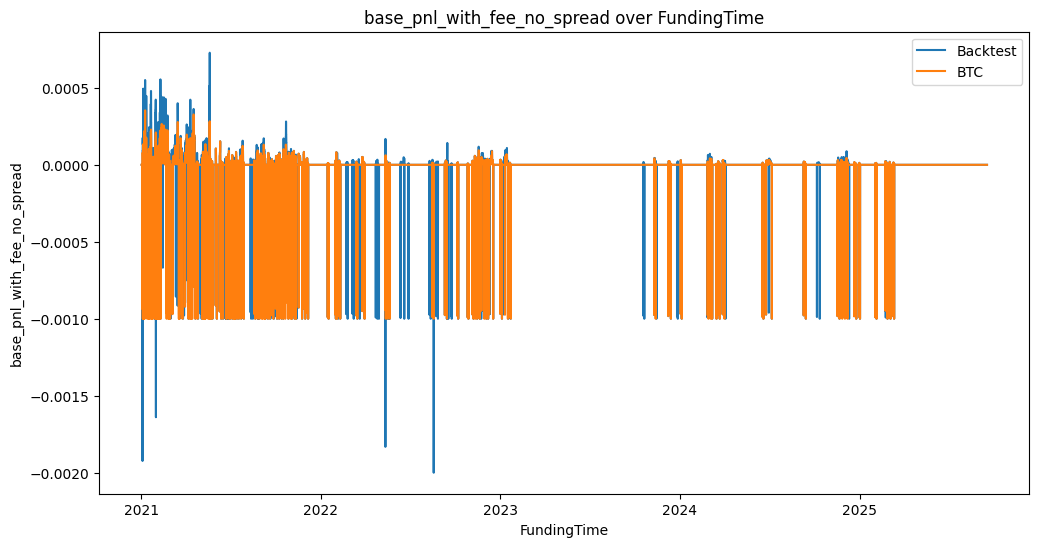

In [108]:
import matplotlib.pyplot as plt

# Ensure FundingTime is datetime
backtest['FundingTime'] = pd.to_datetime(backtest['FundingTime'])
btc['FundingTime'] = pd.to_datetime(btc['FundingTime'])

plt.figure(figsize=(12, 6))
plt.plot(backtest['FundingTime'], backtest['base_pnl_with_fee_no_spread'], label='Backtest')
plt.plot(btc['FundingTime'], btc['base_pnl_with_fee_no_spread'], label='BTC')
plt.xlabel('FundingTime')
plt.ylabel('base_pnl_with_fee_no_spread')
plt.legend()
plt.title('base_pnl_with_fee_no_spread over FundingTime')
plt.show()

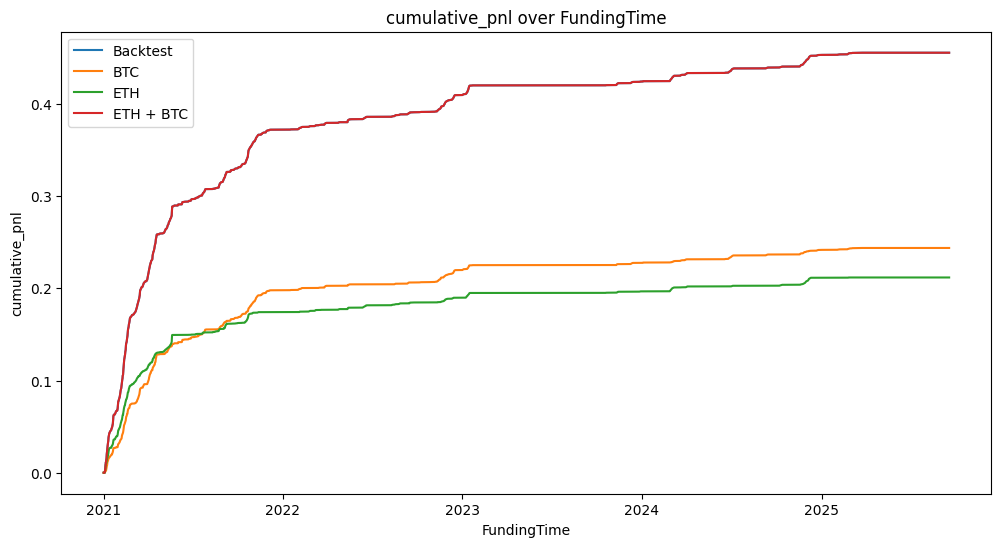

In [109]:
import matplotlib.pyplot as plt

# Ensure FundingTime is datetime
backtest['FundingTime'] = pd.to_datetime(backtest['FundingTime'])
btc['FundingTime'] = pd.to_datetime(btc['FundingTime'])
eth['FundingTime'] = pd.to_datetime(eth['FundingTime'])
plt.figure(figsize=(12, 6))
plt.plot(backtest['FundingTime'], backtest['cumulative_pnl'], label='Backtest')
plt.plot(btc['FundingTime'], btc['cumulative_pnl'], label='BTC')
plt.plot(eth['FundingTime'], eth['cumulative_pnl'], label='ETH')
plt.plot(eth['FundingTime'], eth['cumulative_pnl'] + btc['cumulative_pnl'], label='ETH + BTC')

plt.xlabel('FundingTime')
plt.ylabel('cumulative_pnl')
plt.legend()
plt.title('cumulative_pnl over FundingTime')
plt.show()

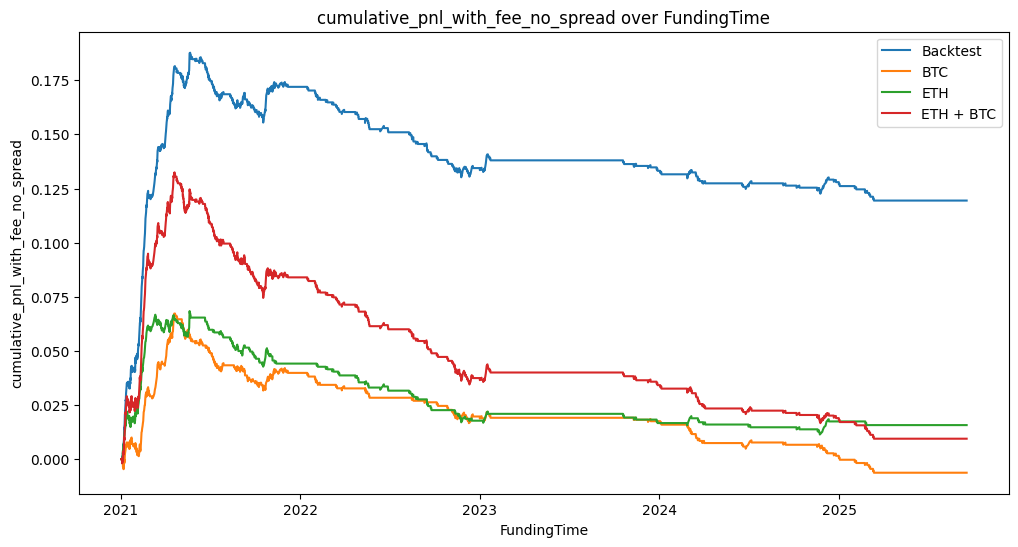

In [110]:
import matplotlib.pyplot as plt

# Ensure FundingTime is datetime
backtest['FundingTime'] = pd.to_datetime(backtest['FundingTime'])
btc['FundingTime'] = pd.to_datetime(btc['FundingTime'])
eth['FundingTime'] = pd.to_datetime(eth['FundingTime'])
plt.figure(figsize=(12, 6))
plt.plot(backtest['FundingTime'], backtest['cumulative_pnl_with_fee_no_spread'], label='Backtest')
plt.plot(btc['FundingTime'], btc['cumulative_pnl_with_fee_no_spread'], label='BTC')
plt.plot(eth['FundingTime'], eth['cumulative_pnl_with_fee_no_spread'], label='ETH')
plt.plot(eth['FundingTime'], eth['cumulative_pnl_with_fee_no_spread'] + btc['cumulative_pnl_with_fee_no_spread'], label='ETH + BTC')

plt.xlabel('FundingTime')
plt.ylabel('cumulative_pnl_with_fee_no_spread')
plt.legend()
plt.title('cumulative_pnl_with_fee_no_spread over FundingTime')
plt.show()

In [103]:
btc

,FundingTime,Binance_FR_1H,Bybit_FR_1H,Diff,Diff_cumsum,diff_mean,signal,position,base_pnl,base_pnl_with_fee_no_spread,base_pnl_with_fee,cumulative_pnl,cumulative_pnl_with_fee_no_spread,cumulative_pnl_with_fee,prev_signal,n_0to1,n_1to0
0,2021-01-01 08:00:00+00:00,0.000033,0.000013,0.000020,0.000020,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
1,2021-01-01 09:00:00+00:00,0.000033,0.000013,0.000020,0.000041,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
2,2021-01-01 10:00:00+00:00,0.000033,0.000013,0.000020,0.000061,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
3,2021-01-01 11:00:00+00:00,0.000033,0.000013,0.000020,0.000082,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
4,2021-01-01 12:00:00+00:00,0.000033,0.000013,0.000020,0.000102,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41275,2025-09-17 03:00:00+00:00,0.000009,0.000010,-0.000001,-0.076992,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0
41276,2025-09-17 04:00:00+00:00,0.000009,0.000010,-0.000001,-0.076993,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0
41277,2025-09-17 05:00:00+00:00,0.000009,0.000010,-0.000001,-0.076994,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0
41278,2025-09-17 06:00:00+00:00,0.000009,0.000010,-0.000001,-0.076996,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0


In [92]:
backtest

,FundingTime,n_0to1,n_1to0,active_symbols,active_positions,allocation,base_pnl,base_pnl_with_fee_no_spread,base_pnl_with_fee,long_trades,short_trades,cumulative_pnl,cumulative_pnl_with_fee_no_spread,cumulative_pnl_with_fee
0,2021-01-01 08:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.00000,0.00000,0.00000
1,2021-01-01 09:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.00000,0.00000,0.00000
2,2021-01-01 10:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.00000,0.00000,0.00000
3,2021-01-01 11:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.00000,0.00000,0.00000
4,2021-01-01 12:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41275,2025-09-17 03:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.45543,0.11943,0.11943
41276,2025-09-17 04:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.45543,0.11943,0.11943
41277,2025-09-17 05:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.45543,0.11943,0.11943
41278,2025-09-17 06:00:00+00:00,0,0,[],0,0,0.0,0.0,0.0,0,0,0.45543,0.11943,0.11943


,FundingTime,Binance_FR_1H,Bybit_FR_1H,Diff,Diff_cumsum,diff_mean,signal,position,base_pnl,base_pnl_with_fee_no_spread,base_pnl_with_fee,cumulative_pnl,cumulative_pnl_with_fee_no_spread,cumulative_pnl_with_fee,prev_signal,n_0to1,n_1to0
0,2021-01-01 08:00:00+00:00,0.000033,0.000013,0.000020,0.000020,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
1,2021-01-01 09:00:00+00:00,0.000033,0.000013,0.000020,0.000041,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
2,2021-01-01 10:00:00+00:00,0.000033,0.000013,0.000020,0.000061,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
3,2021-01-01 11:00:00+00:00,0.000033,0.000013,0.000020,0.000082,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
4,2021-01-01 12:00:00+00:00,0.000033,0.000013,0.000020,0.000102,NaN,0,10000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41275,2025-09-17 03:00:00+00:00,0.000009,0.000010,-0.000001,-0.076992,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0
41276,2025-09-17 04:00:00+00:00,0.000009,0.000010,-0.000001,-0.076993,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0
41277,2025-09-17 05:00:00+00:00,0.000009,0.000010,-0.000001,-0.076994,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0
41278,2025-09-17 06:00:00+00:00,0.000009,0.000010,-0.000001,-0.076996,-0.000002,0,10000,0.0,0.0,0.0,0.243716,-0.006284,-0.006284,0,0,0


In [9]:
since ='2025-01-01'
all_infos = []
batch = []
import pandas as pd
from datetime import datetime, timezone
from tqdm import tqdm
import ccxt
limit = 100
symbol = 'SOL/USDT:USDT'
since_api = None
if since is None:
    since = '2025-01-01'  # Default start date
else:
    since_api = int(pd.to_datetime(since).timestamp() * 1000)  # Convert to ms
now_ts = int(datetime.now(timezone.utc).timestamp() *1000)
prev_last_ts =0
page = 0
limit_per_page = limit if limit and limit < 1000 else 1000
batch = ccxt.bybit().fetch_funding_rate_history(
    symbol,
    since=since_api,
    limit=limit_per_page,
    params={
        "startTime": since_api,
    }
)
# print(f"Error fetching {symbol} on {ccxt.bybit().id}", e)
all_infos.extend(fr['info'] if 'info' in fr else fr for fr in batch)

# Get timestamp from last entry, try different approaches
last_fr = batch[-1]

since_api = last_fr['timestamp']


In [11]:
since ='2025-01-01'
all_infos = []
batch = []
import pandas as pd
from datetime import datetime, timezone
from tqdm import tqdm
import ccxt
limit = 100
symbol = 'SOL/USDT:USDT'
since_api = None
if since is None:
    since = '2021-01-01'  # Default start date
else:
    since_api = int(pd.to_datetime(since).timestamp() * 1000)  # Convert to ms
now_ts = int(datetime.now(timezone.utc).timestamp() *1000)
prev_last_ts =0
page = 0
limit_per_page = limit if limit and limit < 1000 else 1000
with tqdm(desc=f"{ccxt.bybit()} {symbol} funding history", unit="page") as pbar:
    while True:
        try:
            batch = ccxt.bybit().fetch_funding_rate_history(
                symbol,
                since=since_api,
                limit=limit_per_page,
                params={
                    "startTime": since_api,
                }
            )
        except Exception as e:
            print(f"Error fetching {symbol} on {ccxt.bybit().id}", e)
        all_infos.extend(fr['info'] if 'info' in fr else fr for fr in batch)

        # Get timestamp from last entry, try different approaches
        last_fr = batch[-1]

        since_api = last_fr['timestamp']
        if since_api >= now_ts + 1  or since_api == prev_last_ts or len(batch) < limit_per_page:
            print(f"Reached current data at page {page}")
            break                
        page += 1
        pbar.update(1)

Bybit SOL/USDT:USDT funding history: 7page [00:14,  2.08s/page]

Reached current data at page 7


In [13]:
0.045884088749999816 - 46 * 2 * 0.0005 * 2

-0.04611591125000018

In [ ]:
import requests, time
def detect_futures_delist(symbol="neiroethusdt"):  # 小寫比較保險
    url = "https://fapi.binance.com/fapi/v1/exchangeInfo"
    j = requests.get(url, timeout=10).json()
    syminfo = next((s for s in j["symbols"] if s["symbol"].lower()==symbol), None)
    if syminfo and syminfo.get("deliveryDate", 0) > 0:
        return syminfo["deliveryDate"]  # 毫秒，代表有下市時間
    return None

while True:
    ts = detect_futures_delist()
    if ts:
        print("已設定下市時間（毫秒）=", pd.to_datetime(ts,unit='ms'))





        break
    time.sleep(60)

In [6]:
import requests, time
import pandas as pd

In [7]:
url = "https://fapi.binance.com/fapi/v1/exchangeInfo"
j = requests.get(url, timeout=10).json()


In [ ]:
def search_futures_delist():
    url = "https://fapi.binance.com/fapi/v1/exchangeInfo"
    j = requests.get(url, timeout=10).json()
    for s in j["symbols"]:
        if s.get("deliveryDate", 0) > 0:
            delivery_date = pd.to_datetime(s["deliveryDate"],unit='ms')
            if delivery_date < pd.Timestamp.now() + pd.DateOffset(days=30) and delivery_date > pd.Timestamp.now()- pd.DateOffset(days=30):
                print(s["symbol"], delivery_date)

In [11]:
for s in j["symbols"]:
    if s.get("deliveryDate", 0) > 0:
        delivery_date = pd.to_datetime(s["deliveryDate"],unit='ms')
        if delivery_date < pd.Timestamp.now() + pd.DateOffset(days=30) and delivery_date > pd.Timestamp.now()- pd.DateOffset(days=30):
            print(s["symbol"], delivery_date)

MKRUSDT 2025-09-08 09:00:00
ALPHAUSDT 2025-09-23 09:00:00
LEVERUSDT 2025-09-03 09:00:00
OMNIUSDT 2025-09-22 09:00:00
BSWUSDT 2025-09-15 09:00:00
NEIROETHUSDT 2025-09-26 09:00:00
BTCUSDT_250926 2025-09-26 08:00:00
ETHUSDT_250926 2025-09-26 08:00:00


In [15]:
url = "https://dapi.binance.com/dapi/v1/exchangeInfo"
j = requests.get(url, timeout=10).json()


In [16]:
for s in j["symbols"]:
    if s.get("deliveryDate", 0) > 0:
        delivery_date = pd.to_datetime(s["deliveryDate"],unit='ms')
        if delivery_date < pd.Timestamp.now() + pd.DateOffset(days=30) and delivery_date > pd.Timestamp.now()- pd.DateOffset(days=30):
            print(s["symbol"], delivery_date)

BTCUSD_250926 2025-09-26 08:00:00
ETHUSD_250926 2025-09-26 08:00:00
ADAUSD_250926 2025-09-26 08:00:00
LINKUSD_250926 2025-09-26 08:00:00
BCHUSD_250926 2025-09-26 08:00:00
DOTUSD_250926 2025-09-26 08:00:00
XRPUSD_250926 2025-09-26 08:00:00
LTCUSD_250926 2025-09-26 08:00:00
BNBUSD_250926 2025-09-26 08:00:00
SOLUSD_250926 2025-09-26 08:00:00


In [4]:
import pandas as pd
import requests 

In [73]:
params = {
    "symbol": "ASTERUSDT",  # 必填
    "limit": 1000         # 可選：5,10,20,50,100,500,1000...
}


### Funding

In [86]:
aster = requests.get('https://fapi.asterdex.com/fapi/v1/premiumIndex',params=params).json()

In [87]:
aster

{'symbol': 'ASTERUSDT',
 'markPrice': '2.14385800',
 'indexPrice': '2.14149254',
 'estimatedSettlePrice': '2.10309044',
 'lastFundingRate': '0.00150197',
 'interestRate': '0.00000833',
 'nextFundingTime': 1758787200000,
 'time': 1758780185000}

In [88]:
aster = requests.get('https://fapi.asterdex.com/fapi/v1/fundingRate',params=params).json()

In [91]:
df = pd.DataFrame(aster)

In [93]:
df

,symbol,fundingTime,fundingRate
0,ASTERUSDT,1758038400000,0.00010000
1,ASTERUSDT,1758067200000,0.00010000
2,ASTERUSDT,1758096000000,0.00010000
3,ASTERUSDT,1758124800000,0.00010000
4,ASTERUSDT,1758153600000,0.00010000
5,ASTERUSDT,1758182400000,0.00010000
6,ASTERUSDT,1758211200000,0.00010000
7,ASTERUSDT,1758240000001,0.01346750
8,ASTERUSDT,1758247200001,0.02000000
9,ASTERUSDT,1758250800000,0.00200489


In [94]:
df['fundingTime'] = pd.to_datetime(df['fundingTime'], unit='ms')

In [95]:
df

,symbol,fundingTime,fundingRate
0,ASTERUSDT,2025-09-16 16:00:00.000,0.00010000
1,ASTERUSDT,2025-09-17 00:00:00.000,0.00010000
2,ASTERUSDT,2025-09-17 08:00:00.000,0.00010000
3,ASTERUSDT,2025-09-17 16:00:00.000,0.00010000
4,ASTERUSDT,2025-09-18 00:00:00.000,0.00010000
5,ASTERUSDT,2025-09-18 08:00:00.000,0.00010000
6,ASTERUSDT,2025-09-18 16:00:00.000,0.00010000
7,ASTERUSDT,2025-09-19 00:00:00.001,0.01346750
8,ASTERUSDT,2025-09-19 02:00:00.001,0.02000000
9,ASTERUSDT,2025-09-19 03:00:00.000,0.00200489


In [106]:
fund = 0
for i in aster[-6:]:
    fund += float(i['fundingRate'])

In [108]:
fund * 365

3.11348285

In [109]:
fund / 6 / 4 * 24 * 365

3.11348285

In [103]:
aster[-6:]

[{'symbol': 'ASTERUSDT',
  'fundingTime': 1758700800000,
  'fundingRate': '0.00000833'},
 {'symbol': 'ASTERUSDT',
  'fundingTime': 1758715200000,
  'fundingRate': '0.00257615'},
 {'symbol': 'ASTERUSDT',
  'fundingTime': 1758729600000,
  'fundingRate': '0.00043093'},
 {'symbol': 'ASTERUSDT',
  'fundingTime': 1758744000003,
  'fundingRate': '0.00201522'},
 {'symbol': 'ASTERUSDT',
  'fundingTime': 1758758400000,
  'fundingRate': '0.00123203'},
 {'symbol': 'ASTERUSDT',
  'fundingTime': 1758772800000,
  'fundingRate': '0.00226743'}]

### Perps price

In [71]:
aster = requests.get('https://fapi.asterdex.com/fapi/v1/depth',params=params).json()
(float(aster['bids'][0][0]) + float(aster['asks'][0][0])) /2

111792.65

### Spot price

In [72]:
aster = requests.get('https://sapi.asterdex.com/api/v1/depth',params=params).json()
(float(aster['bids'][0][0]) + float(aster['asks'][0][0])) /2

111768.395

In [83]:
def asterusdt_info():
    params = {
    "symbol": "ASTERUSDT",  # 必填
    "limit": 1000         # 可選：5,10,20,50,100,500,1000...
    }
    funding = requests.get('https://fapi.asterdex.com/fapi/v1/premiumIndex',params=params).json()['lastFundingRate']
    funding = float(funding) * 6 * 365
    perps = requests.get('https://fapi.asterdex.com/fapi/v1/depth',params=params).json()
    perps_price = (float(perps['bids'][0][0]) + float(perps['asks'][0][0])) /2
    spot = requests.get('https://sapi.asterdex.com/api/v1/depth',params=params).json()
    spot_price = (float(spot['bids'][0][0]) + float(spot['asks'][0][0])) /2
    return funding, perps_price, spot_price

In [84]:
asterusdt_info()

(3.2938038, 2.12515, 2.116035)

In [114]:
import ast


In [111]:
daily_portfolio = pd.DataFrame({
    "Time": [
        "2023-05-01 10:00:00",
        "2023-05-01 14:30:00",
        "2024-05-02 09:15:00",
        "2024-05-02 13:00:00",
        "2024-06-03 15:45:00",
        "2025-01-04 11:20:00",
    ],
    "symbol": [
        "['AAPL','MSFT']",
        "['AAPL']",
        "['TSLA','MSFT']",
        "['AAPL','TSLA']",
        "['GOOG']",
        "['AAPL','AMZN','MSFT']",
    ]
})

In [118]:

def to_list(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

daily_portfolio['symbol'] = daily_portfolio['symbol'].apply(to_list)

df = daily_portfolio.__deepcopy__()

In [117]:
daily_portfolio

,Time,symbol
0,2023-05-01 10:00:00,"[AAPL, MSFT]"
1,2023-05-01 14:30:00,[AAPL]
2,2024-05-02 09:15:00,"[TSLA, MSFT]"
3,2024-05-02 13:00:00,"[AAPL, TSLA]"
4,2024-06-03 15:45:00,[GOOG]
5,2025-01-04 11:20:00,"[AAPL, AMZN, MSFT]"


In [122]:
df.explode('symbol')[['Time', 'symbol']]

,Time,symbol
0,2023-05-01 10:00:00,AAPL
0,2023-05-01 10:00:00,MSFT
1,2023-05-01 14:30:00,AAPL
2,2024-05-02 09:15:00,TSLA
2,2024-05-02 09:15:00,MSFT
3,2024-05-02 13:00:00,AAPL
3,2024-05-02 13:00:00,TSLA
4,2024-06-03 15:45:00,GOOG
5,2025-01-04 11:20:00,AAPL
5,2025-01-04 11:20:00,AMZN


In [125]:
long = df.explode('symbol')[['Time', 'symbol']]


In [126]:
# Check the structure of long DataFrame
print("long DataFrame:")
print(long)
print("\nTime column dtype:", long['Time'].dtype)
print("Time column sample:", long['Time'].iloc[0])

long DataFrame:
                  Time symbol
0  2023-05-01 10:00:00   AAPL
0  2023-05-01 10:00:00   MSFT
1  2023-05-01 14:30:00   AAPL
2  2024-05-02 09:15:00   TSLA
2  2024-05-02 09:15:00   MSFT
3  2024-05-02 13:00:00   AAPL
3  2024-05-02 13:00:00   TSLA
4  2024-06-03 15:45:00   GOOG
5  2025-01-04 11:20:00   AAPL
5  2025-01-04 11:20:00   AMZN
5  2025-01-04 11:20:00   MSFT

Time column dtype: object
Time column sample: 2023-05-01 10:00:00


In [127]:
presence_daily = (
    long.assign(Time=pd.to_datetime(long['Time']))  # Convert Time to datetime
        .set_index('Time')
        .assign(present=1)
        .groupby([pd.Grouper(freq='D'), 'symbol'])
        .sum()
        .unstack(fill_value=0)
)

In [133]:
long.assign(Time=pd.to_datetime(long['Time'])).set_index('Time').assign(present=1).groupby([pd.Grouper(freq='D'), 'symbol']).sum().unstack(fill_value=0)

present                    
symbol        AAPL AMZN GOOG MSFT TSLA
Time                                  
2023-05-01       2    0    0    1    0
2024-05-02       1    0    0    1    2
2024-06-03       0    0    1    0    0
2025-01-04       1    1    0    1    0

In [134]:
import pandas as pd

data = {
    "date": ["2024-05-01","2024-05-01","2024-05-02","2024-05-02"],
    "symbol": ["AAPL","MSFT","AAPL","TSLA"],
    "present": [1,1,1,1]
}
df = pd.DataFrame(data)
print(df)

         date symbol  present
0  2024-05-01   AAPL        1
1  2024-05-01   MSFT        1
2  2024-05-02   AAPL        1
3  2024-05-02   TSLA        1


In [135]:
df

,date,symbol,present
0,2024-05-01,AAPL,1
1,2024-05-01,MSFT,1
2,2024-05-02,AAPL,1
3,2024-05-02,TSLA,1


In [137]:
g = df.groupby(["date","symbol"]).sum()
g

present
date       symbol         
2024-05-01 AAPL          1
           MSFT          1
2024-05-02 AAPL          1
           TSLA          1

In [138]:
g.unstack(fill_value=0)

present          
symbol        AAPL MSFT TSLA
date                        
2024-05-01       1    1    0
2024-05-02       1    0    1

In [1]:
import ccxt 
import pandas as pd

In [2]:
okxx = ccxt.okx()

In [10]:
okxx.fetchFundingHistory(symbol='SOL/USDT:USDT')

AuthenticationError: okx requires "apiKey" credential

In [37]:
import ccxt 
import pandas as pd

In [38]:
gateio = ccxt.gate()

In [39]:
since = '2023-01-01'
since_api = int(pd.to_datetime(since).timestamp() * 1000)  #

In [40]:
since_api

1672531200000

In [41]:
df = pd.DataFrame(gateio.fetchFundingRateHistory(symbol='SOL/USDT:USDT', limit=100, since=since_api))

In [42]:
gateio.fetchFundingRateHistory(symbol='SOL/USDT:USDT', limit=100, since=since_api)[-1]

{'info': {'r': '0.0001', 't': '1675094400'},
 'symbol': 'SOL/USDT:USDT',
 'fundingRate': 0.0001,
 'timestamp': 1675094400000,
 'datetime': '2023-01-30T16:00:00.000Z'}

In [57]:
all_infos = []

In [ ]:
while True:
    batch = gateio.fetchFundingRateHistory(symbol='SOL/USDT:USDT', limit=100, since=since_api)
    if not batch:
        break
    all_infos.extend( batch)
    since_api = batch[-1]['timestamp'] + 1  # Move to the next timestamp
    print(f"Fetched {len(batch)} records, next since: {pd.to_datetime(since_api, unit='ms')}")


In [59]:
pd.DataFrame(all_infos)

,info,symbol,fundingRate,timestamp,datetime
0,"{'r': '-0.000998', 't': '1672531200'}",SOL/USDT:USDT,-0.000998,1672531200000,2023-01-01T00:00:00.000Z
1,"{'r': '-0.000392', 't': '1672560000'}",SOL/USDT:USDT,-0.000392,1672560000000,2023-01-01T08:00:00.000Z
2,"{'r': '-0.000626', 't': '1672588800'}",SOL/USDT:USDT,-0.000626,1672588800000,2023-01-01T16:00:00.000Z
3,"{'r': '-0.000855', 't': '1672617600'}",SOL/USDT:USDT,-0.000855,1672617600000,2023-01-02T00:00:00.000Z
4,"{'r': '-0.000708', 't': '1672646400'}",SOL/USDT:USDT,-0.000708,1672646400000,2023-01-02T08:00:00.000Z
...,...,...,...,...,...
3071,"{'r': '0.000043', 't': '1760976000'}",SOL/USDT:USDT,0.000043,1760976000000,2025-10-20T16:00:00.000Z
3072,"{'r': '0.000089', 't': '1761004800'}",SOL/USDT:USDT,0.000089,1761004800000,2025-10-21T00:00:00.000Z
3073,"{'r': '0.000066', 't': '1761033600'}",SOL/USDT:USDT,0.000066,1761033600000,2025-10-21T08:00:00.000Z
3074,"{'r': '-0.000038', 't': '1761062400'}",SOL/USDT:USDT,-0.000038,1761062400000,2025-10-21T16:00:00.000Z


In [ ]:
params= {"from":1735689600000}

In [9]:
df = gateio.fetch_ohlcv(symbol='SOL/USDT', timeframe='1h', since=1735689600000, limit=4000)

In [ ]:
df = pd.DataFrame(gateio.fetch_ohlcv(symbol='SOL/USDT', timeframe='1h', since=1672531200000),columns=['timestamp','open','high','low','close','volume'])
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

In [13]:
df

,timestamp,open,high,low,close,volume
0,2025-01-01 00:00:00,189.37,192.67,189.17,192.53,5719.528
1,2025-01-01 01:00:00,192.54,192.63,190.42,190.74,6330.269
2,2025-01-01 02:00:00,190.73,192.03,190.47,191.61,2738.087
3,2025-01-01 03:00:00,191.62,191.62,190.11,190.47,2082.171
4,2025-01-01 04:00:00,190.47,190.47,189.41,189.53,3325.882
...,...,...,...,...,...,...
995,2025-02-11 11:00:00,202.36,203.40,201.95,203.40,2907.271
996,2025-02-11 12:00:00,203.41,203.41,201.43,202.38,4616.075
997,2025-02-11 13:00:00,202.37,202.63,197.81,198.34,8936.720
998,2025-02-11 14:00:00,198.32,200.11,197.89,199.75,9870.579


In [2]:
import requests

In [28]:
since = '2025-01-01'
since_api = int(pd.to_datetime(since).timestamp())  #

In [29]:
since_api

1735689600

In [22]:
all_infos = []

In [35]:
host = "https://api.gateio.ws"
prefix = "/api/v4"
headers = {'Accept': 'application/json', 'Content-Type': 'application/json'}

url = '/futures/usdt/candlesticks'
query_param = {'contract': 'SOL_USDT', 'from': 1672531200, 'to': 1735689600, 'interval': '1h'}
r = requests.request('GET', host + prefix + url, headers=headers, params=query_param)
r

<Response [200]>

In [ ]:
while True:
    query_param = {'contract': 'BTC_USDT', 'from': 1640995200, 'to': since_api, 'interval': '1h'}
    print(pd.to_datetime(1640995200, unit='s'))
    batch = requests.request('GET', host + prefix + url, headers=headers, params=query_param)
    if batch.status_code != 200:
        print("Error fetching data:", batch.text)
        break
    all_infos.extend(batch.json())
    if not batch.json():
        break
    if int(batch.json()[0]['t']) <= 1640995200:
        since_api = int(batch.json()[0]['t']) - 1 
        break
    since_api = int(batch.json()[0]['t']) - 1  # Move to the next timestamp
    print(f"Fetched {len(batch.json())} records, next to: {pd.to_datetime(since_api, unit='s')}")
# query_param = {'contract': 'BTC_USDT', 'from': 1640995200, 'to': since_api, 'interval': '1h'}
# batch = requests.request('GET', host + prefix + url, headers=headers, params=query_param)
# if batch.status_code == 200:
#     all_infos.extend(batch.json())

In [45]:
# Convert timestamp column 't' to datetime and set appropriate column names
df = pd.DataFrame(all_infos)
# df.columns = ['open', 'volume', 'timestamp', 'close', 'low', 'high', 'sum']
# df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
# df.sort_values('timestamp', inplace=True)

In [46]:
df

,o,v,t,c,l,h,sum
0,62281.1,10414655,1728489600,61792.5,61666.6,62319.5,64464729.45682
1,61792.4,2655751,1728493200,61735.3,61653,61884.4,16403825.59088
2,61735.4,10873259,1728496800,61177.3,61083.6,61809.2,66752019.09347
3,61177.3,8277297,1728500400,61022,60803.5,61200,50510203.17521
4,61023,12952108,1728504000,60407.4,60266,61109.6,78608214.81787
...,...,...,...,...,...,...,...
33700,61837.1,2445030,1709395200,61931.1,61700.7,61946.6,15119158.86789
33701,61931,1788870,1709398800,61831,61812.2,62019.2,11077280.15674
33702,61831.1,1157583,1709402400,62094.6,61812.2,62098.5,7175100.99033
33703,62094.6,1429292,1709406000,62185.2,62016.1,62190,8875835.74164
